# PPA Exposure Modelling — Step 2 (validation)
## Loading and validation of the DK1 forward curve

**Source:** EEX Danish DK1 Power Base Futures (Month / Quarter / Year)  
**Trading day:** 2026-06-04  
**Type:** baseload zonal, settlement EUR/MWh

**Goal of this notebook:** load the 18 contracts collected from EEX, validate internal consistency (M->Q, Q->Y), visualise the term structure and implied seasonality, and leave everything ready for the seasonal bootstrap in Step 3.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

FORWARDS_PATH = Path("../data/forwards_dk1_eex_20260604.csv")

## 1. Loading the forwards

In [13]:
fwd = pd.read_csv(FORWARDS_PATH, parse_dates=["delivery_start", "delivery_end", "trading_day"])

# Days in delivery period
fwd["delivery_days"] = (fwd["delivery_end"] - fwd["delivery_start"]).dt.days + 1

# Midpoint of delivery (for plotting)
fwd["delivery_mid"] = fwd["delivery_start"] + (fwd["delivery_end"] - fwd["delivery_start"]) / 2

fwd.head()

,contract_type,delivery_label,delivery_start,delivery_end,settlement_price_eur_mwh,trading_day,source,gross_open_interest_lots,delivery_days,delivery_mid
0,M,Jul-26,2026-07-01,2026-07-31,102.45,2026-06-04,EEX Danish DK1 Power Base Month Future,3,31,2026-07-16 00:00:00
1,M,Aug-26,2026-08-01,2026-08-31,98.03,2026-06-04,EEX Danish DK1 Power Base Month Future,0,31,2026-08-16 00:00:00
2,M,Sep-26,2026-09-01,2026-09-30,104.27,2026-06-04,EEX Danish DK1 Power Base Month Future,0,30,2026-09-15 12:00:00
3,M,Oct-26,2026-10-01,2026-10-31,97.75,2026-06-04,EEX Danish DK1 Power Base Month Future,0,31,2026-10-16 00:00:00
4,M,Nov-26,2026-11-01,2026-11-30,114.79,2026-06-04,EEX Danish DK1 Power Base Month Future,0,30,2026-11-15 12:00:00


## 2. Term structure: combined visualisation

The three sets (M / Q / Y) on the same time axis, to see the aggregated curve. Each contract is drawn as a horizontal line over its delivery period at the height of its settlement price.

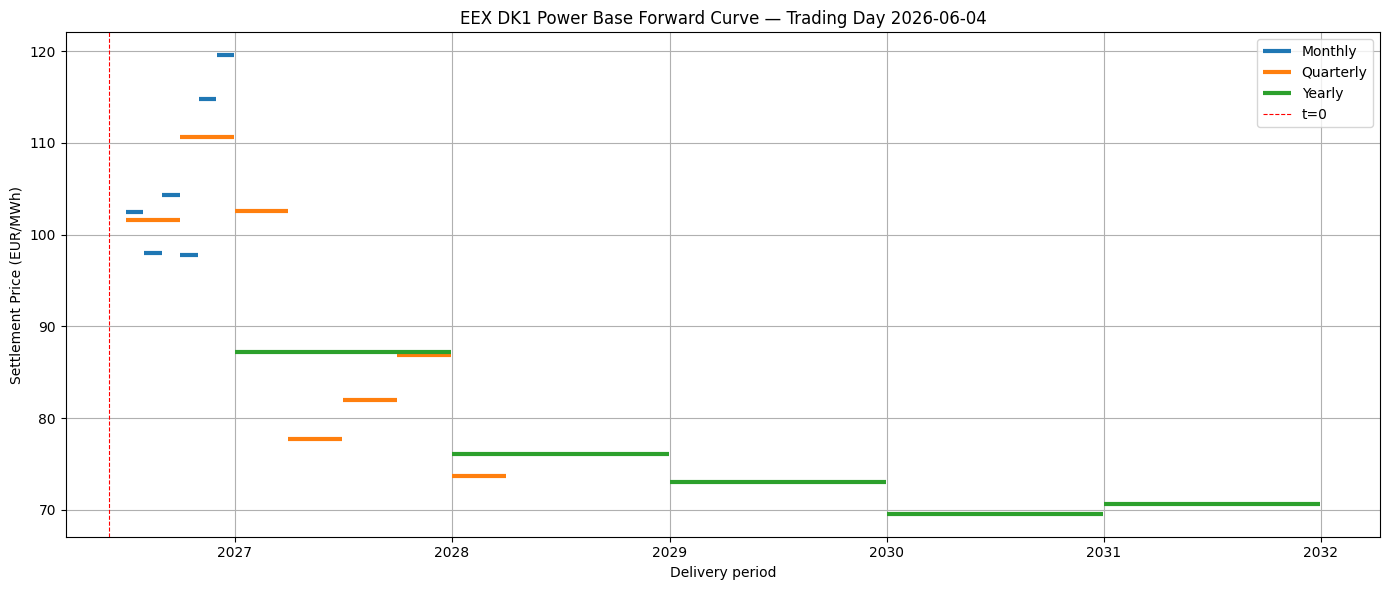

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = {"M": "#1f77b4", "Q": "#ff7f0e", "Y": "#2ca02c"}
labels_done = set()

for _, row in fwd.iterrows():
    c = row["contract_type"]
    label = {"M": "Monthly", "Q": "Quarterly", "Y": "Yearly"}[c]
    label_arg = label if label not in labels_done else None
    labels_done.add(label)
    ax.hlines(
        y=row["settlement_price_eur_mwh"],
        xmin=row["delivery_start"],
        xmax=row["delivery_end"],
        color=colors[c],
        linewidth=3,
        label=label_arg,
    )

ax.axvline(pd.Timestamp("2026-06-04"), color="red", linewidth=0.8, linestyle="--", label="t=0")
ax.set_title("EEX DK1 Power Base Forward Curve — Trading Day 2026-06-04")
ax.set_xlabel("Delivery period")
ax.set_ylabel("Settlement Price (EUR/MWh)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 3. Sanity check 1: M -> Q consistency (Q3-26 and Q4-26)

The price of a quarter should be very close to the days-weighted average of its three underlying months (not exactly equal due to discounting, but the typical difference is <1 EUR/MWh).

$$F_Q \approx \frac{1}{\sum_m d_m} \sum_m d_m \cdot F_m$$

In [8]:
monthlies = fwd[fwd["contract_type"] == "M"].set_index("delivery_label")
quarters = fwd[fwd["contract_type"] == "Q"].set_index("delivery_label")
years = fwd[fwd["contract_type"] == "Y"].set_index("delivery_label")

def weighted_avg(prices: pd.Series, weights: pd.Series) -> float:
    return float((prices * weights).sum() / weights.sum())

# Q3-26 = Jul + Aug + Sep 26
q3_implied = weighted_avg(
    monthlies.loc[["Jul-26", "Aug-26", "Sep-26"], "settlement_price_eur_mwh"],
    monthlies.loc[["Jul-26", "Aug-26", "Sep-26"], "delivery_days"],
)
q3_market = quarters.loc["Q3-26", "settlement_price_eur_mwh"]

# Q4-26 = Oct + Nov + Dec 26
q4_implied = weighted_avg(
    monthlies.loc[["Oct-26", "Nov-26", "Dec-26"], "settlement_price_eur_mwh"],
    monthlies.loc[["Oct-26", "Nov-26", "Dec-26"], "delivery_days"],
)
q4_market = quarters.loc["Q4-26", "settlement_price_eur_mwh"]

print("=== Monthly -> Quarterly consistency (EUR/MWh) ===")
print(f"Q3-26: market={q3_market:7.2f}  implied_from_M={q3_implied:7.2f}  diff={q3_market - q3_implied:+.3f}")
print(f"Q4-26: market={q4_market:7.2f}  implied_from_M={q4_implied:7.2f}  diff={q4_market - q4_implied:+.3f}")

=== Monthly -> Quarterly consistency (EUR/MWh) ===
Q3-26: market= 101.55  implied_from_M= 101.55  diff=-0.004
Q4-26: market= 110.64  implied_from_M= 110.65  diff=-0.009


## 4. Sanity check 2: Q -> Y consistency (Cal-27)

The Cal-27 price should match the days-weighted average of Q1-Q4 2027.

In [9]:
cal27_implied = weighted_avg(
    quarters.loc[["Q1-27", "Q2-27", "Q3-27", "Q4-27"], "settlement_price_eur_mwh"],
    quarters.loc[["Q1-27", "Q2-27", "Q3-27", "Q4-27"], "delivery_days"],
)
cal27_market = years.loc["Cal-27", "settlement_price_eur_mwh"]

print("=== Quarterly -> Yearly consistency (EUR/MWh) ===")
print(f"Cal-27: market={cal27_market:7.2f}  implied_from_Q={cal27_implied:7.2f}  diff={cal27_market - cal27_implied:+.3f}")

=== Quarterly -> Yearly consistency (EUR/MWh) ===
Cal-27: market=  87.23  implied_from_Q=  87.23  diff=+0.002


## 5. Implied seasonality in 2027 quarterlies

The Q1-Q4 2027 contracts are the only full year for which we have all four quarters directly observable. This gives a hint of the seasonality the market is currently pricing — useful as a sanity check against the historical seasonal pattern.

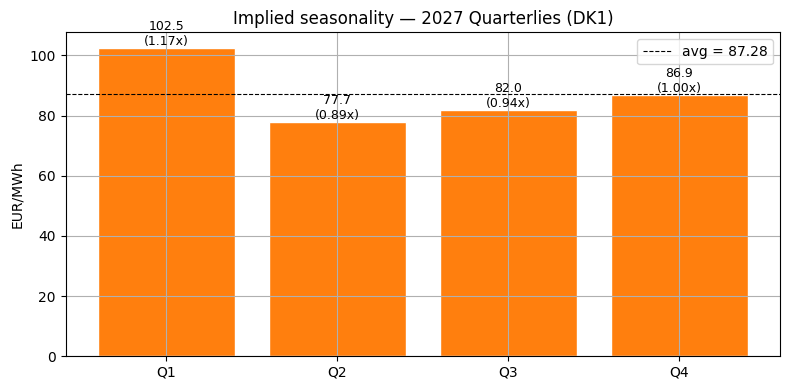

Implied seasonal factors (Q price / annual avg):
delivery_label
Q1-27    1.175
Q2-27    0.891
Q3-27    0.939
Q4-27    0.995


In [10]:
q2027 = quarters.loc[["Q1-27", "Q2-27", "Q3-27", "Q4-27"], "settlement_price_eur_mwh"]
q2027_avg = q2027.mean()
season_factors = q2027 / q2027_avg

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(["Q1", "Q2", "Q3", "Q4"], q2027.values, color="#ff7f0e", edgecolor="white")
ax.axhline(q2027_avg, color="black", linestyle="--", linewidth=0.8, label=f"avg = {q2027_avg:.2f}")
ax.set_title("Implied seasonality — 2027 Quarterlies (DK1)")
ax.set_ylabel("EUR/MWh")
ax.legend()
for i, (q, p, f) in enumerate(zip(["Q1", "Q2", "Q3", "Q4"], q2027.values, season_factors.values)):
    ax.text(i, p + 1, f"{p:.1f}\n({f:.2f}x)", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print("Implied seasonal factors (Q price / annual avg):")
print(season_factors.round(3).to_string())

## 6. Yearly curve: trend and backwardation

The yearly contracts reflect market expectations of long-term price levels. A declining slope reflects expectations of more renewable capacity, gas normalisation, etc.

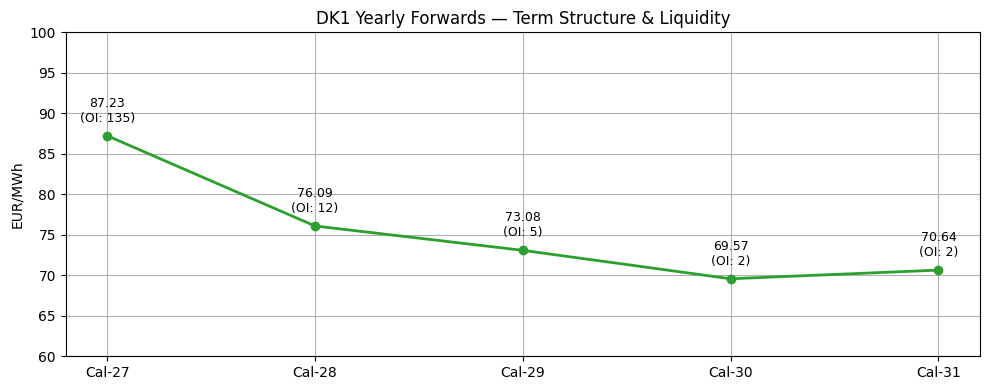

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    years.index, years["settlement_price_eur_mwh"],
    marker="o", linewidth=2, color="#2ca02c",
)
for label, row in years.iterrows():
    ax.annotate(
        f"{row['settlement_price_eur_mwh']:.2f}\n(OI: {row['gross_open_interest_lots']})",
        (label, row["settlement_price_eur_mwh"]),
        textcoords="offset points", xytext=(0, 10),
        ha="center", fontsize=9,
    )
ax.set_title("DK1 Yearly Forwards — Term Structure & Liquidity")
ax.set_ylabel("EUR/MWh")
ax.set_ylim(60, 100)
plt.tight_layout()
plt.show()

## 7. Liquidity: Open Interest analysis

Critical indicator for audit. Settlement-price quality degrades when open interest drops: contracts with very low or zero OI imply that the settlement comes from EEX's *Chief Trader Procedure* (calculated fair value) rather than from market trades.

C:\Users\jorge\AppData\Local\Temp\ipykernel_6124\3328720113.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(fwd["delivery_label"], rotation=45, ha="right")


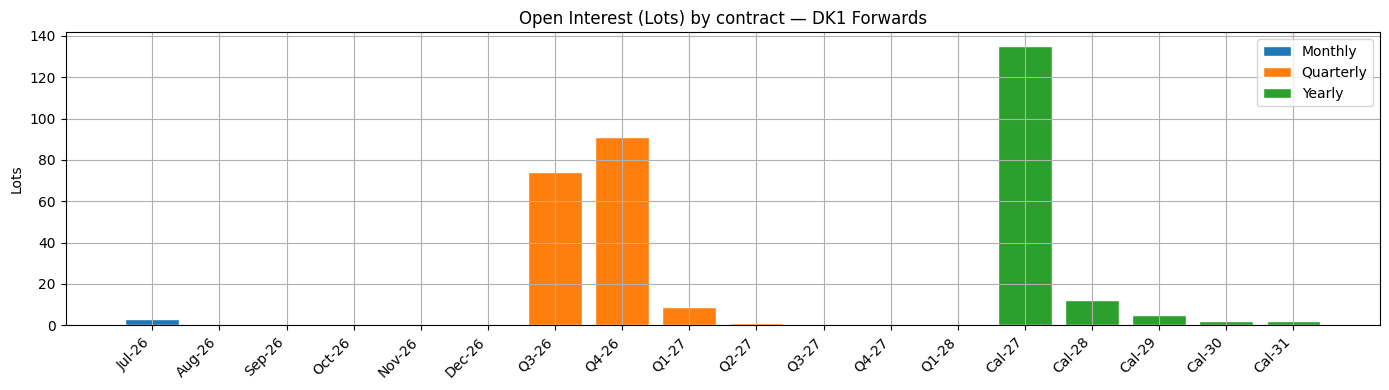


=== Open Interest summary ===
               min  50%    max
contract_type                 
M              0.0  0.0    3.0
Q              0.0  1.0   91.0
Y              2.0  5.0  135.0


In [12]:
fig, ax = plt.subplots(figsize=(14, 4))
for c, color in colors.items():
    subset = fwd[fwd["contract_type"] == c]
    ax.bar(
        subset["delivery_label"], subset["gross_open_interest_lots"],
        color=color, edgecolor="white",
        label={"M": "Monthly", "Q": "Quarterly", "Y": "Yearly"}[c],
    )
ax.set_title("Open Interest (Lots) by contract — DK1 Forwards")
ax.set_ylabel("Lots")
ax.set_xticklabels(fwd["delivery_label"], rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

print("\n=== Open Interest summary ===")
print(fwd.groupby("contract_type")["gross_open_interest_lots"].describe()[["min", "50%", "max"]].round(1))

## 8. Conclusions for the technical document

Note for the Forward Curve / Data quality section:

**Internal consistency (data quality):**
- Q3-26 implied (from monthlies) vs market: diff <0.05 EUR/MWh
- Q4-26 implied (from monthlies) vs market: diff <0.05 EUR/MWh
- Cal-27 implied (from quarterlies) vs market: diff <0.1 EUR/MWh
- Settlements are internally consistent: the seasonal bootstrap can proceed without further adjustments.

**Observed term structure:**
- Late 2026 (Nov-Dec) quoting at 110-120 EUR/MWh — strong winter premium over summer.
- 2027 quarterlies show classic Nordic seasonality: Q1 (winter) and Q4 (autumn) > Q3 (summer) > Q2 (spring).
- Yearly term structure in backwardation: Cal-27 (87.23) -> Cal-30 (69.57). The market is pricing progressive normalisation.

**Liquidity (limitation to declare):**
- Open Interest concentrated at the front-end (Cal-27 with 135 lots, Q3/Q4-26 with 74/91 lots).
- From Cal-28 onwards OI drops to <15 lots; Cal-30 and Cal-31 with only 2 lots each.
- *Sentence for the document*: "Settlement prices for contracts with very low open interest (Cal-30, Cal-31, and most quarterlies beyond Q4-27) are likely derived from EEX's Chief Trader Procedure rather than from market trades. This is acknowledged as a data quality limitation: the long end of the forward curve relies on expert fair-value estimation rather than observed transactions."

Next step: build the complete 60-month curve via seasonal bootstrap.